In [2]:
#Name: Alexandro Galvez-Vega
#Team: Alexandro Galvez-Vega and Victor Neyra
#Class: CAP 5625-042 Computational Foundations Of AI
#Professor: Michael DeGiorgio

In [2]:
#Starting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

In [3]:
filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

#This dataframe is quickly split between the features that will be used for x

x_features_df = advertising_df.copy(deep = True)


#Our goal is to determine credit card balance which is separated into its own df here

y_features_df = x_features_df.pop("Balance") 

In [4]:

#Converting the categorical columns from the dataset
x_features_df = pd.get_dummies(x_features_df, columns = ["Gender"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Married"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Student"], drop_first=True, dtype=int)

In [5]:
x_features_df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender_Male,Married_Yes,Student_Yes
0,14.891,3606,283,2,34,11,1,1,0
1,106.025,6645,483,3,82,15,0,1,1
2,104.593,7075,514,4,71,11,1,0,0
3,148.924,9504,681,3,36,11,0,0,0
4,55.882,4897,357,2,68,16,1,1,0


In [7]:

#For the purposes of the assignment, we are using ridge regression
#which requires standardization of the data
y_standardized = y_features_df - y_features_df.mean()

#Here we are standardizing the numerical columns of the data set.
#numerical_features = ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education']
#X_standardized = x_features_df.copy()
#X_standardized[numerical_features] = (x_features_df[numerical_features] - x_features_df[numerical_features].mean()) / x_features_df[numerical_features].std()


## TA pointed out that encoded features need to be standardized as well
X_standardized = (x_features_df - x_features_df.mean()) / x_features_df.std()





In [8]:
#We add a dummy 1 column for the future matrix math involving beta which will include a beta_0
# x_standardized_add1 = X_standardized.assign(dummy=1)
# moving_column = x_standardized_add1.pop("dummy") 
# x_standardized_add1.insert(0, "beta_0", moving_column)

x_standardized_add1 = X_standardized




#This time the starting learning rate is 10 ^ -5
learning_rate_alpha = 10 ** -5

tuning_parameter = 10 ** -2
tuning_parameters_set = [10**-2,10**-1,10**0,10**1,10**2,10**3,10**4]
#tuning_parameter = 0


k_fold = 5  

#We get the total number of observations involved
observations_N = len(X_standardized)

#We note the total number of features too
feature_total_p = len(x_standardized_add1.columns)

#The dataframes are converted to numpy arrays to allow for the matrix math that is going to be involved
X = x_standardized_add1.to_numpy()



y = y_standardized.to_numpy()

#This is also provided a1 and represents the bath based on the batch_size_n noted split
k_N_Splits = observations_N // k_fold 


#"Note, that a standardized coefficients are always in a range between -1 and +1"
#Random is used to give us a random initial beta, -1 and 1 are used as a range

#initial_beta = np.random.uniform(-1, 1, feature_total_p)
initial_beta = np.random.uniform(-1, 1, feature_total_p)


In [9]:
#This is redundant but I set beta to initial beta
#I wanted to have a variable specifically for the intial randomally set beta
intermediary_beta = initial_beta
#Beta refined will act as final beta
#This is also a little redundant but I want a clear variable for this as well

#Placeholder until final values are estbalished
vector_param_beta = initial_beta

#variable to keep track of all beta resuls for graphing
record_of_v_beta = []


#variable to keep track of the cost history for graphing
record_of_cost = []

#The iteration loop size is set to 20,000
# _ is used instead of commas for python
iter_loops = 100_000

In [10]:


cross_validation_account_final = []
vector_parameter_beta_final = []

cross_validation_beta_account_final = []

for current_tuning_paremeter in tuning_parameters_set:
    tuning_parameter = current_tuning_paremeter
    random_reorder = np.random.permutation(observations_N)
    cross_validation_account = []
    
    cross_validation_beta_account = []
    for fold in range(k_fold):
        intermediary_beta = initial_beta.copy()


        beg_index = fold * k_N_Splits
        end_index = (fold + 1) * k_N_Splits
        beg_to_end_indexes = np.arange(beg_index, end_index)



        validation_unit = random_reorder[beg_to_end_indexes]
        X_validation_set = X[validation_unit]
        y_validation_set = y[validation_unit]

        X_training_set = np.delete(X, validation_unit, axis=0)
        y_training_set = np.delete(y, validation_unit, axis=0)


        for iter_c in range(iter_loops):

            #X transpose is needed for the equation
            X_training_transposed = np.transpose(X_training_set)
            #The math here can be found from a1
            #Referred to module 4 slides for understanding
            update_pv_p1 = X_training_transposed.dot(y_training_set - X_training_set.dot(intermediary_beta))
            #update_pv_p2 = ((tuning_parameter * intermediary_beta) - update_pv_p1)
            update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
            intermediary_beta += 2 * learning_rate_alpha * update_pv_p2

        y_vaidation__set_predicted = X_validation_set.dot(intermediary_beta)

        validation_error = np.sum((y_validation_set - y_vaidation__set_predicted)**2) / len(y_validation_set)
        cross_validation_account.append(validation_error)
        
        cross_validation_beta_account.append(intermediary_beta)
        #print(validation_error)

    cross_validation_error = np.mean(cross_validation_account)
    cross_validation_account_final.append(cross_validation_error)
    vector_parameter_beta_final.append(intermediary_beta)
    
    cross_validation_beta_account_final.append(np.mean(cross_validation_beta_account, axis=0))
    #print(cross_validation_error)
print(cross_validation_account_final)









[9777.143790520935, 9850.541736892244, 9951.32184540075, 10677.70877187213, 29664.82550728321, 106679.02167132245, 189958.232991266]


In [11]:
print(vector_parameter_beta_final)

[array([-273.50895847,  396.55118463,  215.70999702,   20.20645369,
        -12.28119807,   -2.81561247,    5.69693272,   -4.08959035,
        127.54313076]), array([-2.73421268e+02,  3.73612894e+02,  2.43807335e+02,  1.90199532e+01,
       -1.09672277e+01, -7.46397603e-02,  4.64262281e+00, -7.80024531e+00,
        1.26193350e+02]), array([-269.19378823,  394.2424494 ,  218.2305973 ,   22.73631425,
        -13.38221402,   -2.379671  ,    6.02389432,   -2.8953053 ,
        129.52290084]), array([-232.09413236,  291.8183349 ,  278.82892994,   17.62962512,
        -14.18015859,   -3.33172892,   -0.98065771,   -3.95340136,
        122.73098839]), array([-7.58141387e+01,  1.99222769e+02,  1.98469687e+02,  2.13597938e+01,
       -2.03204428e+01, -1.76196883e+00,  1.96916906e-01, -6.70378648e+00,
        9.43976044e+01]), array([24.62495926, 73.91920305, 73.67790137,  5.25230518, -0.69652127,
        1.71506663, -0.5525427 , -0.57776933, 25.50960868]), array([ 6.2336814 , 11.83357168, 11.9242

In [12]:
vector_parameter_beta_final_means = np.mean(vector_parameter_beta_final)

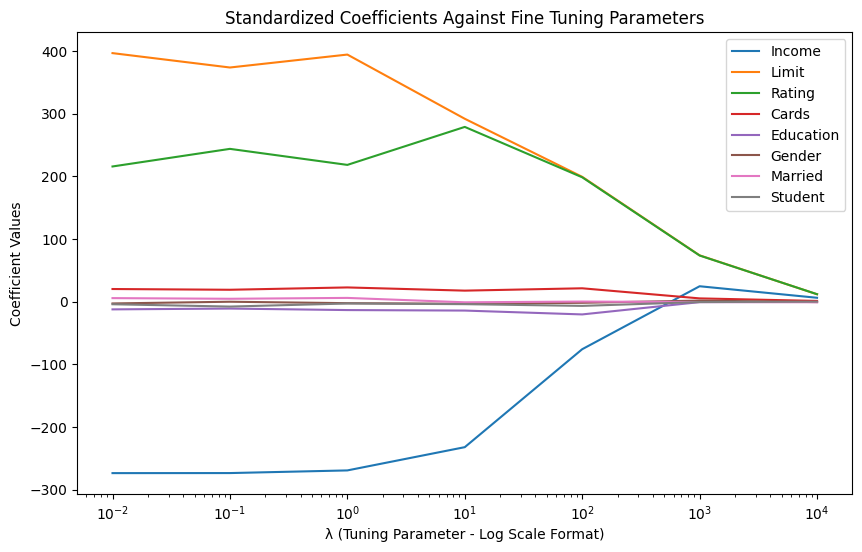

In [13]:
vector_parameter_beta_final_np = np.array(vector_parameter_beta_final)
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes
plt.figure(figsize=(10, 6))


plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,0], label="Income")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,1], label="Limit")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,2], label="Rating")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,3], label="Cards")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,4], label="Education")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,5], label="Gender")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,6], label="Married")
plt.semilogx(tuning_parameters_set, vector_parameter_beta_final_np[:,7], label="Student")
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Coefficient Values')
plt.title('Standardized Coefficients Against Fine Tuning Parameters')
plt.legend()
plt.show()

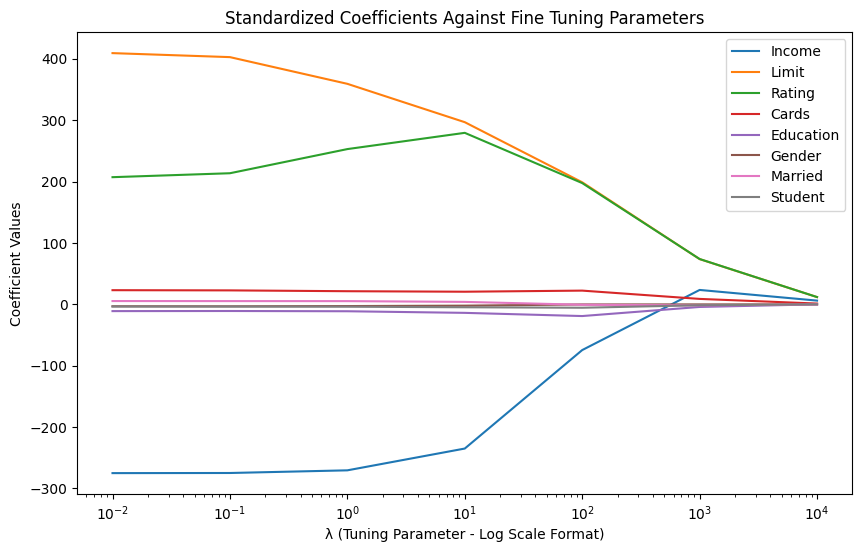

In [14]:
cross_validation_beta_account_final_np = np.array(cross_validation_beta_account_final)
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes
plt.figure(figsize=(10, 6))


plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,0], label="Income")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,1], label="Limit")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,2], label="Rating")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,3], label="Cards")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,4], label="Education")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,5], label="Gender")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,6], label="Married")
plt.semilogx(tuning_parameters_set, cross_validation_beta_account_final_np[:,7], label="Student")
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Coefficient Values')
plt.title('Standardized Coefficients Against Fine Tuning Parameters')
plt.legend()
plt.show()

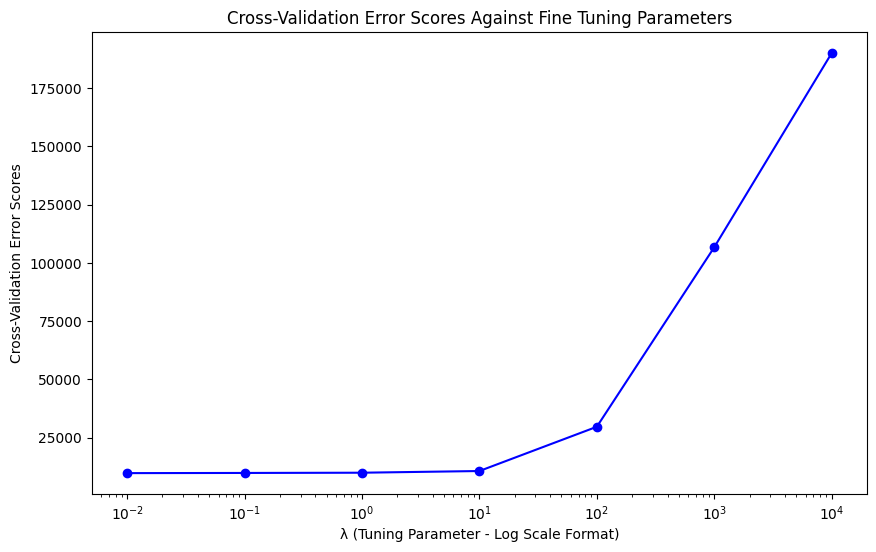

In [15]:
plt.figure(figsize=(10, 6))
plt.semilogx(tuning_parameters_set, cross_validation_account_final, 'bo-')
plt.xlabel('λ (Tuning Parameter - Log Scale Format)')
plt.ylabel('Cross-Validation Error Scores')
plt.title('Cross-Validation Error Scores Against Fine Tuning Parameters')
plt.show()

In [16]:
lowest_cross_validation_error = min(cross_validation_account_final)
print("The lowest cross-validation score achieved: " + str(lowest_cross_validation_error))

The lowest cross-validation score achieved: 9777.143790520935


In [17]:
tuning_parameter_lowest_cv = 0
for i in range(len(cross_validation_account_final)):
    if cross_validation_account_final[i] == lowest_cross_validation_error:
        tuning_parameter_lowest_cv = tuning_parameters_set[i]

print("The fine tuning parameter that resulted in the lowest cross-validation score: " + str(tuning_parameter_lowest_cv))
#print(tuning_parameter_lowest_cv)


The fine tuning parameter that resulted in the lowest cross-validation score: 0.01


In [18]:

cross_validation_account_final = []
vector_parameter_beta_final = []

cross_validation_beta_account_final = []


tuning_parameter = tuning_parameter_lowest_cv
random_reorder = np.random.permutation(observations_N)
intermediary_beta = initial_beta.copy()
X_final = X[random_reorder]
y_final = y[random_reorder]

for iter_c in range(iter_loops):
        #lkmlkml
        X_final_transposed = np.transpose(X_final)
        #The math here can be found from a1
        update_pv_p1 = X_final_transposed.dot(y_final - X_final.dot(intermediary_beta))
        #update_pv_p2 = ((tuning_parameter * intermediary_beta) - update_pv_p1)
        update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
        intermediary_beta += 2 * learning_rate_alpha * update_pv_p2

y_final_predicted = X_final.dot(intermediary_beta)
mean_squared_error = np.sum((y_final - y_final_predicted)**2) / len(y_final)
final_vector_param_beta = intermediary_beta


In [20]:
print("9 Best Fit Model Parameters Based On Tuning Parameter That Produced The Lowest Cross-Validation Error Score: ")
#Income	Limit	Rating	Cards	Age	Education	Gender_Male	Married_Yes	Student_Yes


print("Income: " + str(round(final_vector_param_beta[0], 4)))
print("Limit: " + str(round(final_vector_param_beta[1], 4)))
print("Rating: " + str(round(final_vector_param_beta[2], 4)))
print("Cards: " + str(round(final_vector_param_beta[3], 4)))
print("Age: " + str(round(final_vector_param_beta[4], 4)))
print("Education: " + str(round(final_vector_param_beta[5], 4)))
print("Gender: " + str(round(final_vector_param_beta[6], 4)))
print("Married: " + str(round(final_vector_param_beta[7], 4)))
print("Student: " + str(round(final_vector_param_beta[8], 4)))


9 Best Fit Model Parameters Based On Tuning Parameter That Produced The Lowest Cross-Validation Error Score: 
Income: -274.9976
Limit: 420.0315
Rating: 196.2328
Cards: 23.4715
Age: -10.9789
Education: -3.3508
Gender: 5.2075
Married: -3.6005
Student: 127.9427
